In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_excel("glass.xlsx",sheet_name="glass")

print(df.head())
print(df.info())
print(df.describe())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
     

In [3]:
print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [5]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

1


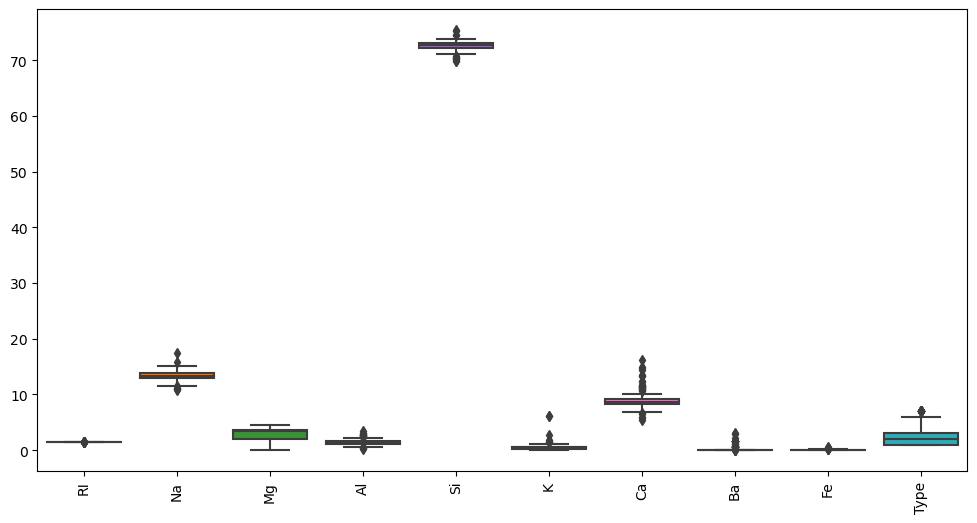

In [6]:
#boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [7]:
from scipy import stats
df = df[(np.abs(stats.zscore(df.select_dtypes(include=[np.number]))) < 3).all(axis=1)]

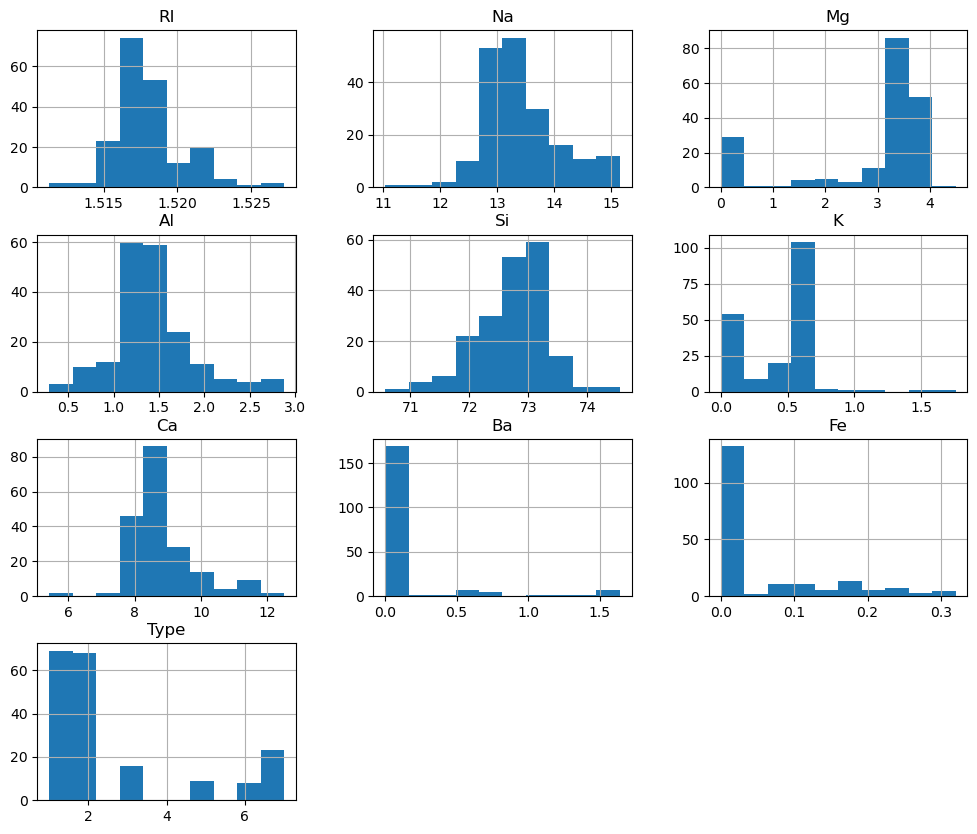

In [8]:
#histogram
df.hist(figsize=(12,10))
plt.show()

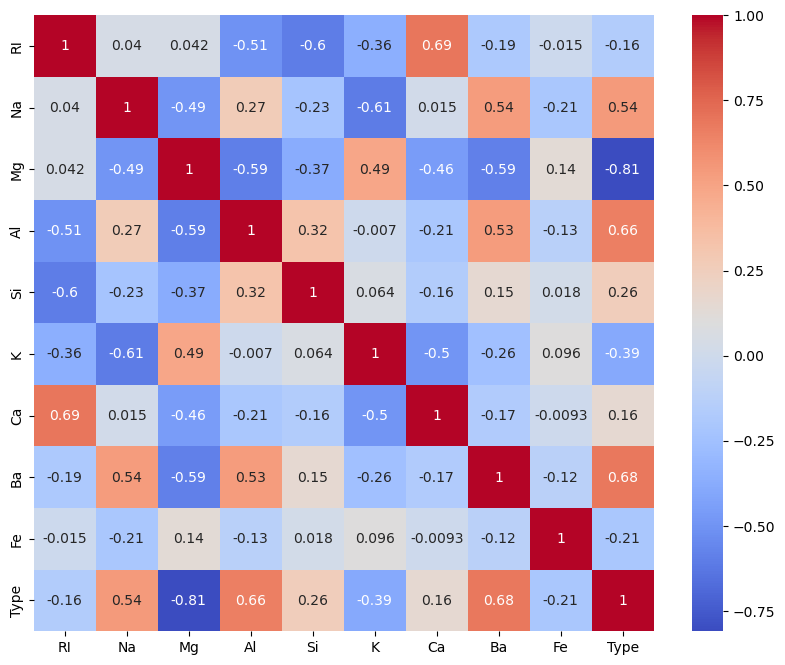

In [9]:
#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

E:\Users\SUGANYA P\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


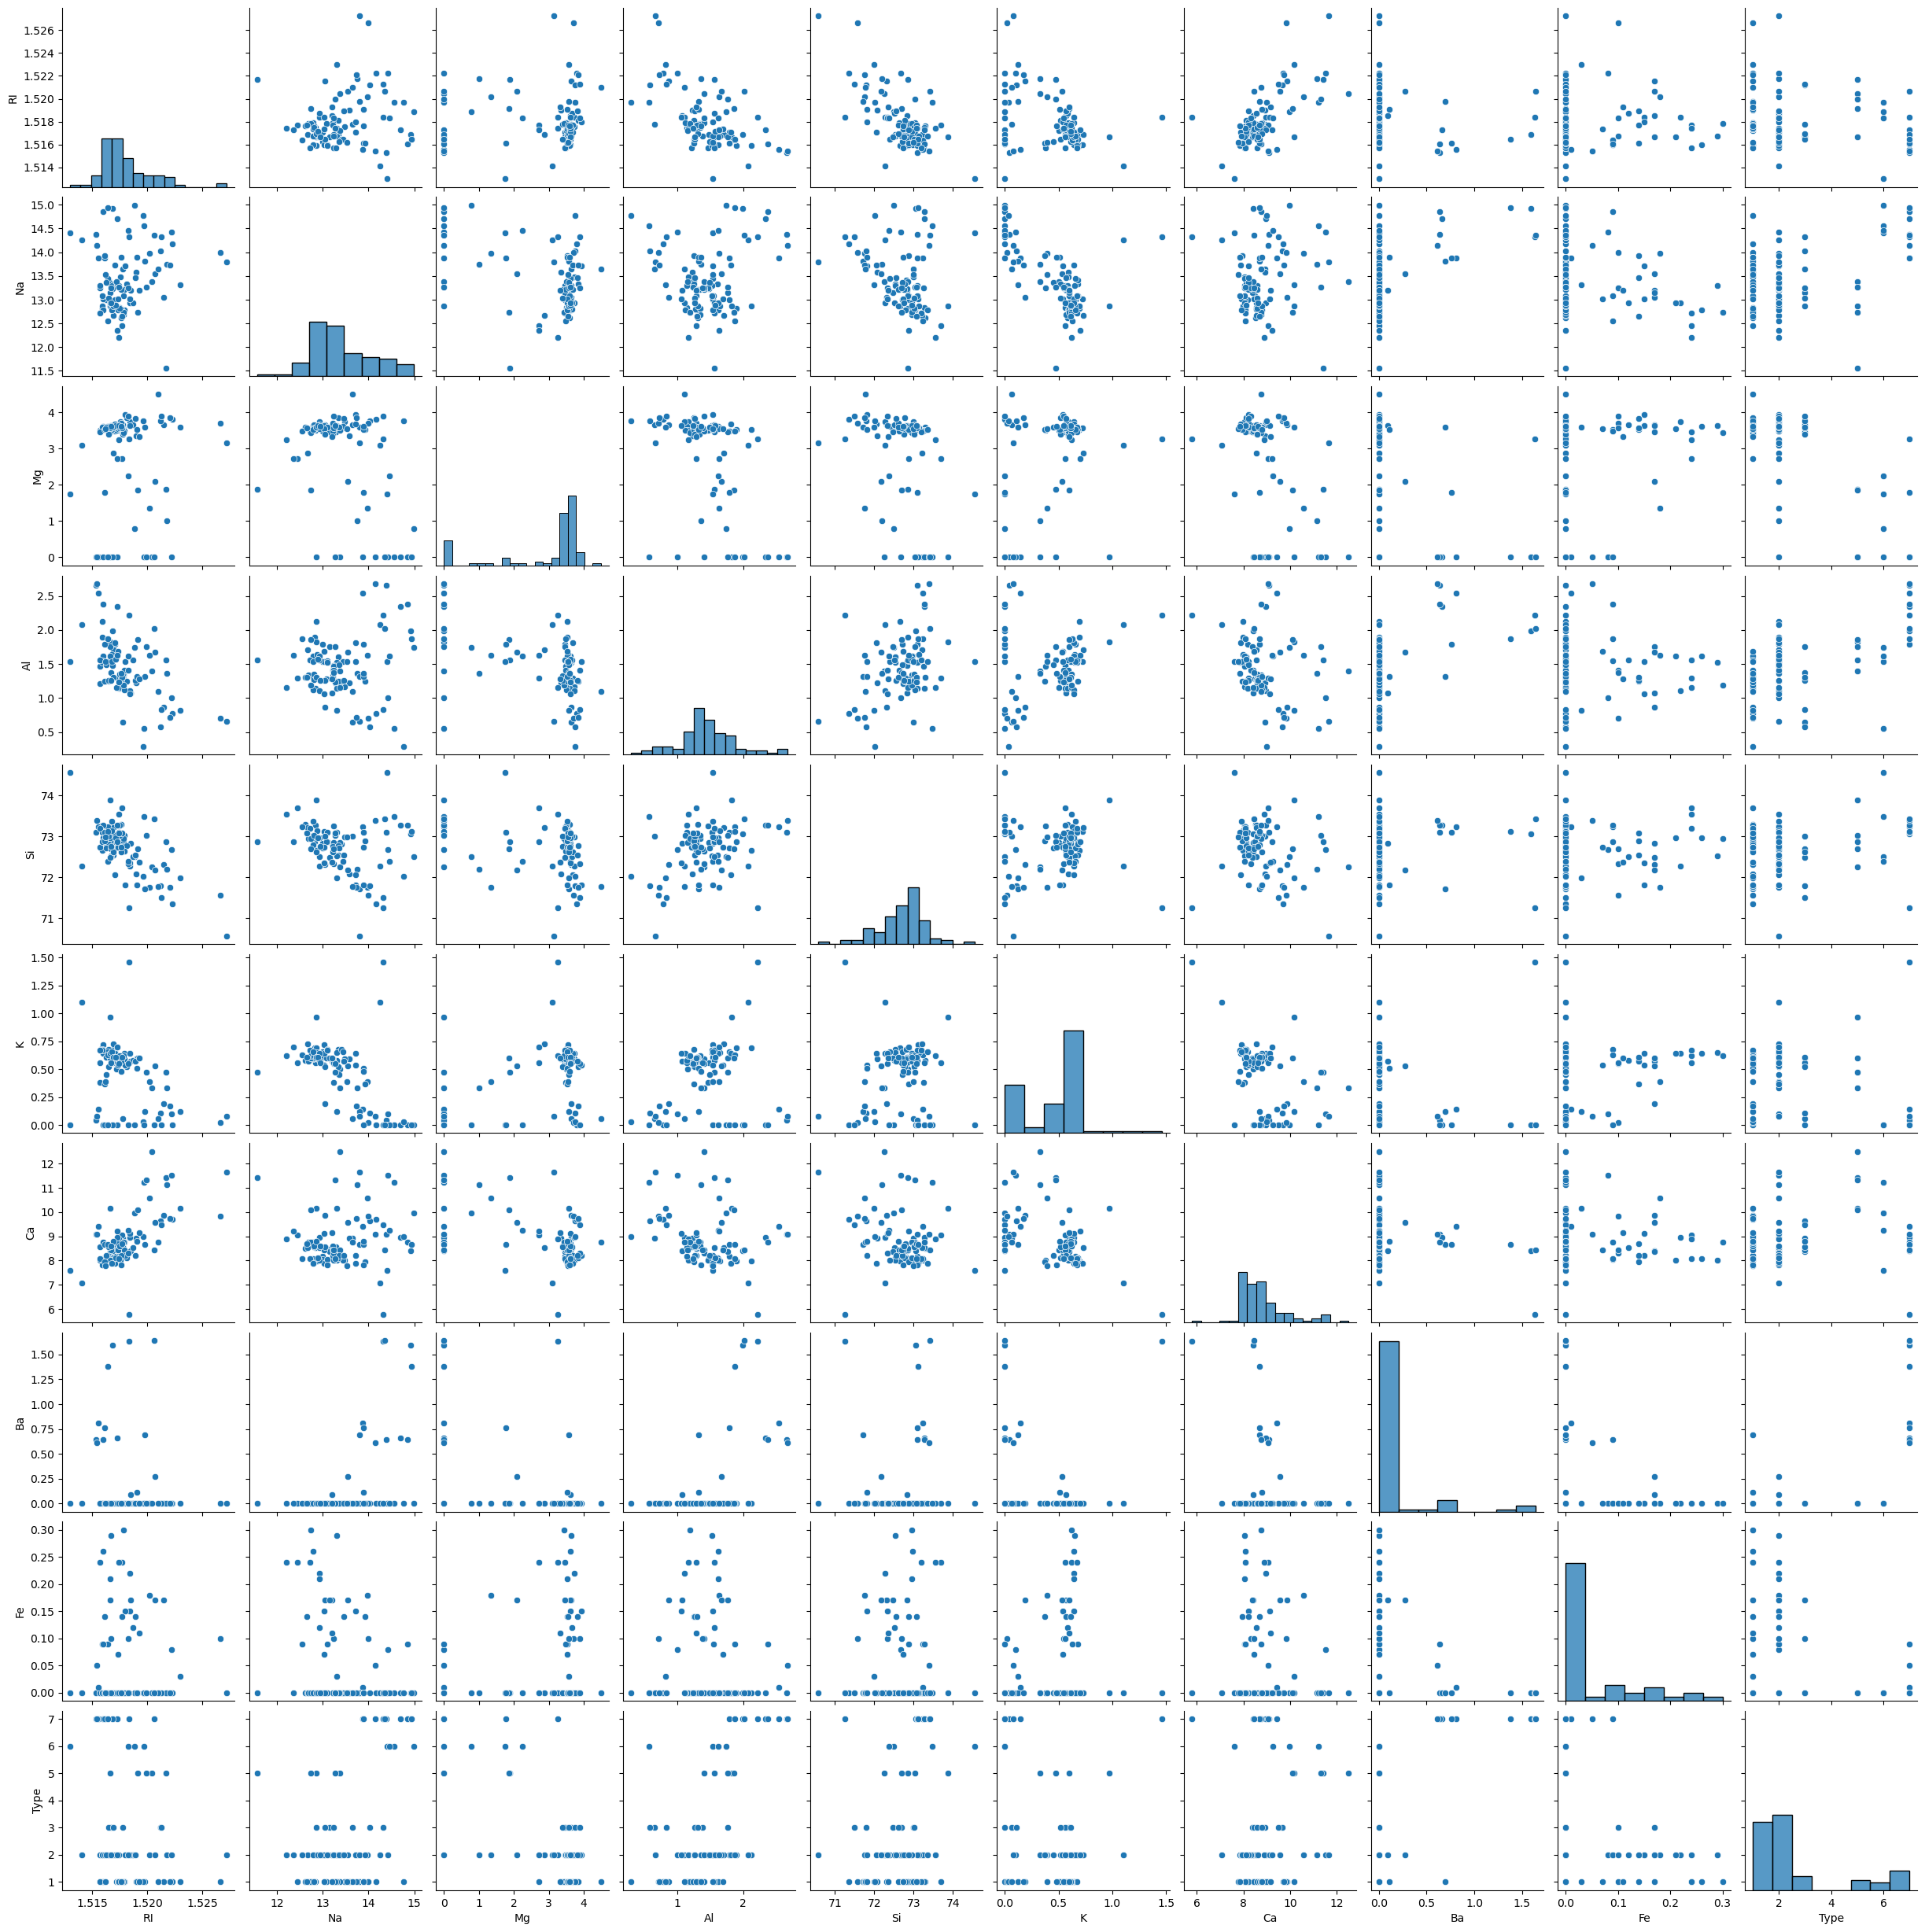

In [10]:
#pairplot
sns.pairplot(df.sample(100))
plt.show()

In [11]:
X = df.drop("Type", axis=1)   # Target column = Type
y = df["Type"]

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
from sklearn.preprocessing import MinMaxScaler

# MinMax Scaling
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7435897435897436
              precision    recall  f1-score   support

           1       0.67      0.71      0.69        14
           2       0.69      0.92      0.79        12
           3       1.00      0.17      0.29         6
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         1

    accuracy                           0.74        39
   macro avg       0.89      0.80      0.79        39
weighted avg       0.78      0.74      0.71        39



In [17]:
bagging = BaggingClassifier(
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))

Bagging Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           1       0.58      0.50      0.54        14
           2       0.61      0.92      0.73        12
           3       1.00      0.17      0.29         6
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         2
           7       0.50      1.00      0.67         1

    accuracy                           0.67        39
   macro avg       0.78      0.76      0.70        39
weighted avg       0.72      0.67      0.63        39



In [18]:
boost = AdaBoostClassifier(n_estimators=100, random_state=42)

boost.fit(X_train, y_train)
y_pred_boost = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost))

Boosting Accuracy: 0.41025641025641024
              precision    recall  f1-score   support

           1       0.43      0.93      0.59        14
           2       0.00      0.00      0.00        12
           3       0.00      0.00      0.00         6
           5       0.00      0.00      0.00         4
           6       0.67      1.00      0.80         2
           7       0.50      1.00      0.67         1

    accuracy                           0.41        39
   macro avg       0.27      0.49      0.34        39
weighted avg       0.20      0.41      0.27        39



C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\SUGANYA P\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

In [19]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Random Forest Accuracy: 0.7435897435897436
Bagging Accuracy: 0.6666666666666666
Boosting Accuracy: 0.41025641025641024
